# Customer Retention Strategy Analysis

## Business Problem
A D2C fashion brand wants to understand whether customers are genuinely loyal or mainly driven by discounts.

### Objectives
- Identify high value customers
- Measure promotion dependency
- Build loyalty metrics
- Analyze customer behavior
- Generate retention recommendation


## 1. Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import sqlite3

pd.set_option('display.max_columns', None)


## 2. Load Dataset
Read customer transactional and behavioral data.

In [21]:
df = pd.read_csv('../data/Dataset.csv')

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 3. Dataset Understanding

In [22]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

df.info()

Rows: 3900
Columns: 18
<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900

## 4. Data Quality Check
Check missing values and duplicate records before analysis.

In [23]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [24]:
df = df.dropna()

print('Rows after cleaning:', len(df))

Rows after cleaning: 3863


In [25]:
df.duplicated().sum()

np.int64(0)

## 5. Exploratory Data Analysis (EDA)
Understand revenue, products and customer behavior.

### Revenue by Category

In [26]:
category_revenue = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

category_revenue

Category
Clothing       102968
Accessories     73480
Footwear        35778
Outerwear       18403
Name: Purchase Amount (USD), dtype: int64

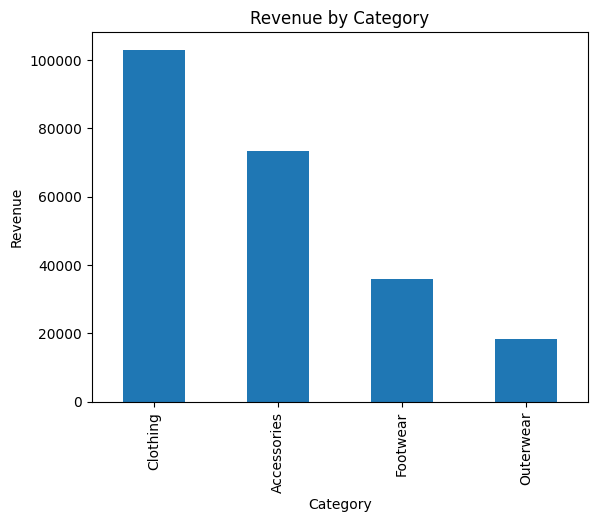

In [27]:
category_revenue.plot(kind='bar')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

### Discount Usage Analysis

In [28]:
df['Discount Applied'].value_counts()

Discount Applied
No     2223
Yes    1640
Name: count, dtype: int64

### Average Spending by Product Category

In [29]:
df.groupby('Category')['Purchase Amount (USD)'].mean().sort_values(ascending=False)

Category
Footwear       60.232323
Clothing       59.934808
Accessories    59.788446
Outerwear      57.152174
Name: Purchase Amount (USD), dtype: float64

## 6. Feature Engineering
Create business metrics for customer intelligence.

### Annual Purchase Frequency

In [30]:
freq_map = {
    "Weekly": 52,
    "Fortnightly": 26,
    "Bi-Weekly": 26,
    "Monthly": 12,
    "Every 3 Months": 4,
    "Quarterly": 4,
    "Annually": 1
}

df['annual_frequency'] = df['Frequency of Purchases'].map(freq_map)

df[['Frequency of Purchases','annual_frequency']].head()

,Frequency of Purchases,annual_frequency
0,Fortnightly,26
1,Fortnightly,26
2,Weekly,52
3,Weekly,52
4,Annually,1


### Promo Dependency Score
Higher value means customer relies more on promotions.

In [31]:
df['Discount Applied'] = df['Discount Applied'].map({'Yes':1,'No':0})
df['Promo Code Used'] = df['Promo Code Used'].map({'Yes':1,'No':0})

df['promo_dependency'] = (
    0.6*df['Discount Applied']+
    0.4*df['Promo Code Used']
)

df[['promo_dependency']].head()

,promo_dependency
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


## 7. Loyalty Model Creation
Loyalty is defined using repeat behavior, purchase frequency, spending and satisfaction.

In [32]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(
    df[['Purchase Amount (USD)',
        'Previous Purchases',
        'annual_frequency',
        'Review Rating']]
)

scaled_df = pd.DataFrame(
    scaled,
    columns=[
        'purchase_scaled',
        'previous_scaled',
        'frequency_scaled',
        'review_scaled'
    ],
    index=df.index
)

df = pd.concat([df, scaled_df], axis=1)


In [33]:
df['loyalty_score'] = (
    0.4*df['previous_scaled']+
    0.3*df['frequency_scaled']+
    0.2*df['purchase_scaled']+
    0.1*df['review_scaled']
)

df[['loyalty_score']].head()

,loyalty_score
0,0.359681
1,0.289222
2,0.636092
3,0.906837
4,0.325398


## 8. Customer Segmentation

In [34]:
def customer_tier(score):
    if score >= 0.75:
        return 'High Value'
    elif score >= 0.45:
        return 'Medium Value'
    else:
        return 'Low Value'

df['value_tier'] = df['loyalty_score'].apply(customer_tier)

df['value_tier'].value_counts()

value_tier
Low Value       2042
Medium Value    1654
High Value       167
Name: count, dtype: int64

## 9. Loyalty vs Promotion Dependency

In [35]:
df.groupby('value_tier')[['loyalty_score','promo_dependency']].mean()

,loyalty_score,promo_dependency
value_tier,,
High Value,0.816458,0.443114
Low Value,0.316264,0.422135
Medium Value,0.566469,0.425635


## 10. Category Loyalty Analysis

In [36]:
df.groupby('Category')['loyalty_score'].mean().sort_values(ascending=False)

Category
Footwear       0.450003
Accessories    0.448280
Clothing       0.442529
Outerwear      0.436634
Name: loyalty_score, dtype: float64

## 11. Export Final Analytical Dataset

In [37]:
df.to_csv('../data/customer_features.csv', index=False)

print('Dataset exported successfully')

Dataset exported successfully


# Final Business Insights

1. Clothing generated the highest revenue and loyalty.
2. Footwear customers showed high spending behavior.
3. Customer segmentation revealed different retention opportunities.
4. Promo dependency score helps identify discount-sensitive customers.
5. Loyalty-based targeting can improve retention strategy.

## Recommended Actions

- Reduce blanket promotions
- Protect loyal customers with experience benefits
- Target low-value customers with personalized retention campaigns
